
# Tutorial 6 — **Seaborn**: Visualizaciones estadísticas prácticas


**Objetivo**: Crear gráficos **estilizados** y **estadísticos** con **Seaborn**, aprovechar `hue`/`col`/`row`, *facets*, paletas y estimadores (promedio, suma, *error bars*).

> Seaborn se apoya en Matplotlib y facilita gráficos estadísticos con un diseño por defecto más elegante e integración nativa con **DataFrames**. 



<a id="material"></a>
## 1) Material de estudio



<a id="por-que"></a>
### 1.1 ¿Por qué **Seaborn**?
- **Estilo por defecto atractivo** (menos ajustes manuales).
- Integra **Pandas DataFrames**: funciona directo con columnas por nombre.
- **Gráficos estadísticos** de alto nivel: `barplot`, `boxplot`, `violinplot`, `histplot`, `kdeplot`, `lmplot` (regresión), `catplot`, `pairplot`, `heatmap`, etc.



<a id="carga"></a>
### 1.2 Cargar datos de ejemplo

Si usted quisiera podría utilizar los CSV del Tutorial 3, para ver

Sin embargo ahora se mostrará con un DataFrame simulado.


In [1]:

import pandas as pd
import numpy as np

print("Simulando un DataFrame...")
rng = np.random.default_rng(0)
fechas = pd.date_range("2024-01-01", periods=180, freq="D")
ventas = pd.DataFrame({
    "id_venta": range(1, len(fechas)+1),
    "id_cliente": rng.integers(1000, 1050, size=len(fechas)),
    "id_producto": rng.integers(2001, 2008, size=len(fechas)),
    "fecha_venta": fechas,
    "cantidad": rng.integers(1, 6, size=len(fechas)),
    "sucursal_id": rng.integers(1, 4, size=len(fechas))
})
productos = pd.DataFrame({
    "id_producto":[2001,2002,2003,2004,2005,2006,2007],
    "producto":["Notebook 14","Notebook 15","Mouse","Teclado","Monitor 24","Monitor 27","Impresora"],
    "categoria":["Computación","Computación","Accesorios","Accesorios","Audio/Video","Audio/Video","Computación"],
    "precio":[499000,599000,19990,39990,159990,219990,129990]
})
sucursales = pd.DataFrame({
    "sucursal_id":[1,2,3],
    "sucursal":["Centro","Norte","Sur"],
    "ciudad":["Santiago","Antofagasta","Concepción"],
    "region":["RM","II","VIII"]
})
regiones = pd.DataFrame({"region":["RM","II","VIII"], "pais":["Chile","Chile","Chile"]})

print("ventas:", ventas.shape, "| productos:", productos.shape, "| sucursales:", sucursales.shape)

Simulando un DataFrame...
ventas: (180, 6) | productos: (7, 4) | sucursales: (3, 4)



<a id="estilos"></a>
### 1.3 Estilos y paletas

Con **Seaborn** podemos establecer un estilo global y **paletas** de color:
- `sns.set_theme(style="whitegrid", context="notebook", palette="deep")`
- Paletas útiles: `"deep"`, `"muted"`, `"pastel"`, `"dark"`, `"colorblind"`, o funciones como `sns.color_palette("viridis", as_cmap=True)` para mapas de color.


In [2]:

import seaborn as sns
import matplotlib.pyplot as plt

print("Aplicando tema global de Seaborn (whitegrid)...")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")

# Unir info de productos/sucursales para ejemplos
v = ventas.merge(productos, left_on="id_producto", right_on="id_producto", how="left")
v = v.merge(sucursales, on="sucursal_id", how="left")
v["mes"] = v["fecha_venta"].dt.to_period("M").dt.to_timestamp()

print("Columnas disponibles en v:", list(v.columns)[:10], "...")

Aplicando tema global de Seaborn (whitegrid)...
Columnas disponibles en v: ['id_venta', 'id_cliente', 'id_producto', 'fecha_venta', 'cantidad', 'sucursal_id', 'producto', 'categoria', 'precio', 'sucursal'] ...



<a id="basicos"></a>
### 1.4 Gráficos básicos

**Relacionales**:
- `sns.scatterplot(data=..., x=..., y=..., hue=..., style=...)`
- `sns.lineplot(...)` (agrega estimadores por defecto si hay repetidos; usa `estimator=None` para trazar cada observación)

**Categóricos**:
- `sns.barplot(..., estimator='mean'|'sum', errorbar='sd'|'se'|None)`
- `sns.countplot(...)` (conteo por categoría)
- `sns.boxplot(...)` / `sns.violinplot(...)` (distribuciones por categoría)

**Distribuciones**:
- `sns.histplot(...)`, `sns.kdeplot(...)`, `sns.displot(...)`


Ejemplos básicos: scatter, bar y histograma con Seaborn


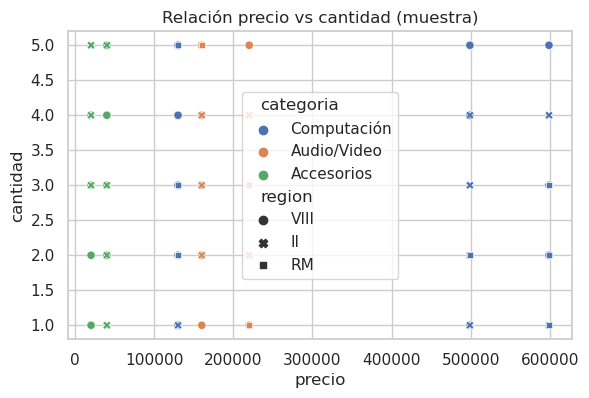

In [4]:

print("Ejemplos básicos: scatter, bar y histograma con Seaborn")

# Scatter: precio vs cantidad (muestra)
muestra = v.sample(min(400, len(v)), random_state=0)
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.scatterplot(data=muestra, x="precio", y="cantidad", hue="categoria", style="region", ax=ax)
ax.set_title("Relación precio vs cantidad (muestra)")
plt.show()


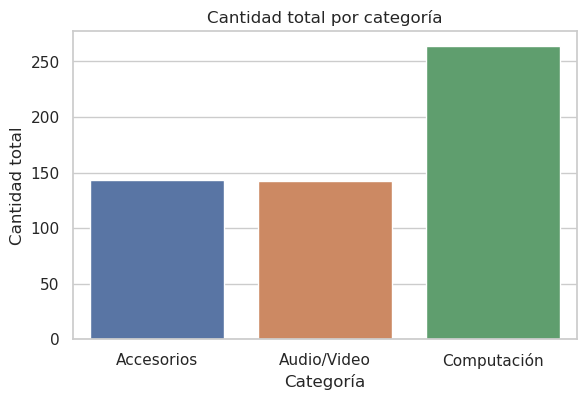

In [5]:

# Barras: total vendido por categoría (suma de cantidad)
res_cat = v.groupby("categoria", as_index=False)["cantidad"].sum()
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.barplot(data=res_cat, x="categoria", y="cantidad", ax=ax, errorbar=None, estimator="sum")
ax.set_title("Cantidad total por categoría")
ax.set_xlabel("Categoría"); ax.set_ylabel("Cantidad total")
plt.show()


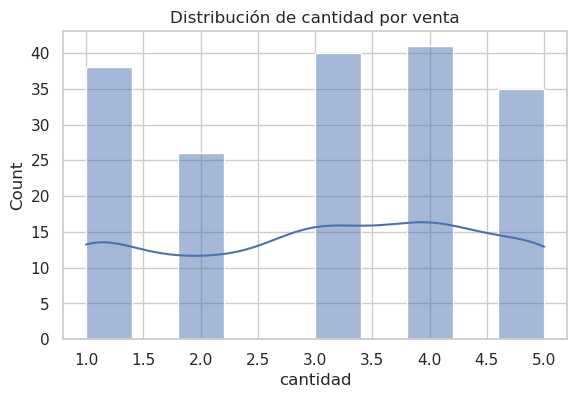

In [6]:

# Histograma: distribución de cantidades
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.histplot(data=v, x="cantidad", bins=10, kde=True, ax=ax)
ax.set_title("Distribución de cantidad por venta")
plt.show()


<a id="facetas"></a>
### 1.5 Facetas (FacetGrid / catplot)

**Facetado**: dividir la visualización por subgrupos para comparar patrones:  
- `sns.catplot(..., col='region', row='categoria', kind='bar')`  
- `sns.relplot(..., col='categoria', kind='line')`  
- `sns.FacetGrid(...).map(...)` para control fino.


Ejemplo con facetas: tendencia mensual por categoría (línea con hue=region)


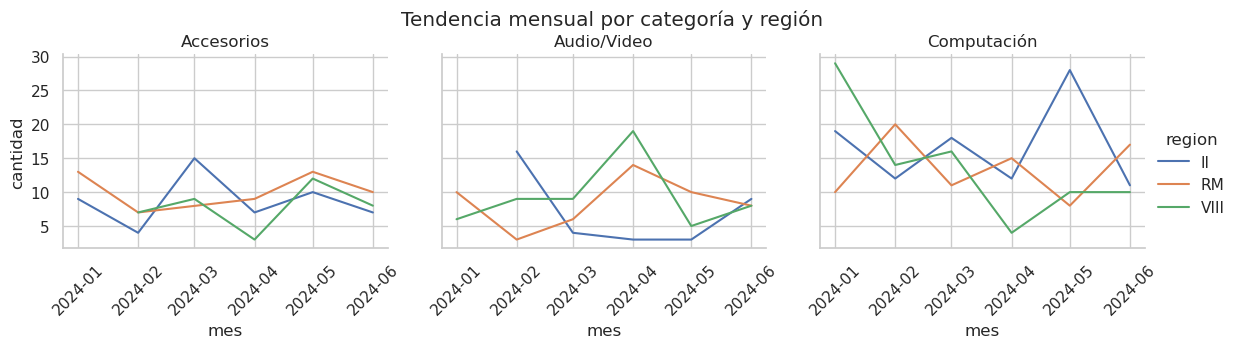

In [7]:

print("Ejemplo con facetas: tendencia mensual por categoría (línea con hue=region)")
trend = v.groupby(["mes","categoria","region"], as_index=False)["cantidad"].sum()

g = sns.relplot(
    data=trend, x="mes", y="cantidad",
    hue="region", col="categoria",
    kind="line", col_wrap=3, height=3.0, aspect=1.3
)
g.set_titles(col_template="{col_name}")
for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=45)
g.fig.suptitle("Tendencia mensual por categoría y región", y=1.02)
plt.show()


<a id="heatmap"></a>
### 1.6 Mapas de calor y correlaciones

- `sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')`  


Mapa de calor: correlación entre variables numéricas


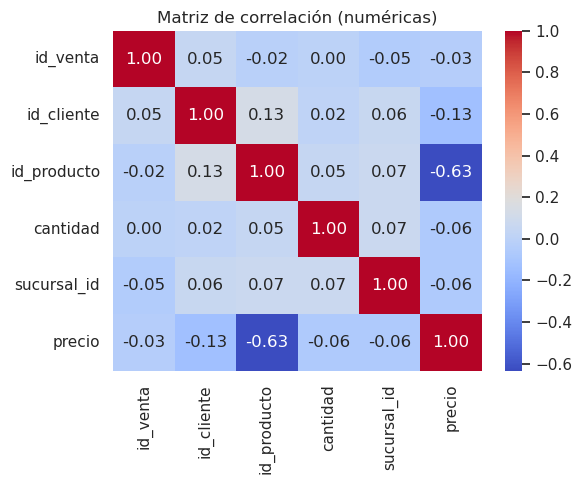

In [8]:

print("Mapa de calor: correlación entre variables numéricas")
num_cols = v.select_dtypes(include=["number"]).columns
corr = v[num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Matriz de correlación (numéricas)")
plt.tight_layout()
plt.show()


<a id="savefig"></a>
### 1.7 Guardar figuras

Seaborn usa Matplotlib por debajo, por lo que puedes guardar con `fig.savefig(...)`.


Guardando un gráfico de barras en PNG...
Archivo guardado: seaborn_barplot_export.png


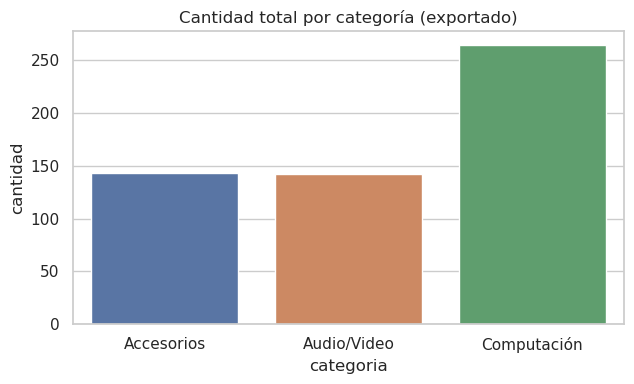

In [9]:

print("Guardando un gráfico de barras en PNG...")
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 4))
sns.barplot(data=res_cat, x="categoria", y="cantidad", ax=ax, errorbar=None, estimator="sum")
ax.set_title("Cantidad total por categoría (exportado)")
fig.tight_layout()
fig.savefig("seaborn_barplot_export.png", dpi=150)
print("Archivo guardado: seaborn_barplot_export.png")


<a id="ejercicios"></a>
## 2) Ejercicios

**Formato**: usa títulos, etiquetas de ejes/leyendas y **mensajes descriptivos** con `print(...)` para guiar el output.




### Ejercicio 1 — Barras por categoría (sumas)
1) Une `ventas × productos` por `id_producto`.  
2) Calcula la **suma** de `cantidad` por `categoria`.  
3) Grafica un **barplot** con `estimator="sum"` (sin barras de error).  
4) Ordena las categorías de mayor a menor.



### Ejercicio 2 — Distribución y cajas
1) Grafica la **distribución** de `cantidad` con `histplot` (agrega `kde=True`).  
2) Crea un **boxplot** de `cantidad` por `categoria` (y añade `hue="region"` si tienes sucursales).  
3) Comenta si hay asimetrías u outliers.



### Ejercicio 3 — Relacional con regresión
1) Muestra la relación **precio vs cantidad** con `scatterplot`.  
2) Añade una línea de **regresión** con `sns.regplot(...)` (en una figura aparte o sobre la misma si quieres comparar).  
3) ¿Se observa alguna tendencia o patrón por `categoria`/`region` (usa `hue`/`style`)?



### Ejercicio 4 — Facetado temporal
1) Agrega una columna `mes` = primer día del mes (`to_period('M')`).  
2) Calcula cantidad mensual por `categoria` y `region`.  
3) Grafica una **línea** con `relplot(kind='line', col='categoria', hue='region')`.  
4) Rota *ticks* y añade un título general.



### Ejercicio 5 — Calor/Correlación
1) Calcula una **matriz de correlación** con columnas numéricas.  
2) Dibuja un **heatmap** con `annot=True`.  
3) (Opcional) Crea una **tabla dinámica** (categoría × mes) con la suma de `cantidad` y represéntala como `heatmap`.
